In [259]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core.custom_primitives.random_variable import rv
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

from functools import partial

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.helpers import Flip

import optax
from optax import adam

import jax
from jax import numpy as jnp

In [260]:
def simulator_two_moons(key, theta0, theta1):
    """Simulator for the two moons problem."""
    key1, key2 = jax.random.split(key)
    p = Normal(0.1, 0.01)
    u = Uniform(-0.5 * jnp.pi, 0.5 * jnp.pi)
    noise1 = rv(p, "r")
    noise2 = rv(u, "alpha")
    r = noise1(key1)
    alpha = noise2(key2)
    rhs1 = (r * jnp.cos(alpha) + 0.25) + (-jnp.abs(theta0 + theta1) / jnp.sqrt(2.))
    rhs2 = (r * jnp.sin(alpha)) + ((theta1 - theta0) / jnp.sqrt(2.))

    return rhs1, rhs2

In [261]:
thetas = Uniform(-1., 1.).sample(jax.random.PRNGKey(0), (100000, 2))
xs = jnp.stack(jax.vmap(simulator_two_moons)(jax.random.split(jax.random.PRNGKey(0), thetas.shape[0]), thetas[:, 0], thetas[:, 1]), axis=1)

In [262]:
context_dim = 2
input_dim = 2

In [263]:

# Base distribution
p = Independent(Normal(jnp.zeros(input_dim), jnp.ones(input_dim)), 1)

def spline_bijector(params, x):
    return rational_quadratic_spline(params, x, range_min_x=-4, range_max_x=4,range_min_y = -1., range_max_y=1.)

num_bins = 8
bijector_dim = (3 * num_bins)
split_dim = input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x, context):
    net1 = CouplingMLP(1, spline_bijector, bijector_dim, context_dim=2)
    net2 = CouplingMLP(1, spline_bijector, bijector_dim, context_dim=2)
    net3 = CouplingMLP(1, spline_bijector, bijector_dim, context_dim=2)
    
    x1 = net1(x, context)
    x1 = Flip()(x1)
    x2 = net2(x1, context)
    x2 = Flip()(x2)
    x3 = net3(x2, context)
    return x3

init, apply = forward.init, forward.apply
params = init(jax.random.PRNGKey(0), jnp.ones((input_dim,)), jnp.ones((context_dim,)))
T = apply

[2] []


In [264]:
optimizer = adam(1e-3)
opt_state = optimizer.init(params)


# Train
@partial(jax.vmap, in_axes=(None, 0, 0))
def log_prob(params, x, context):
    q = TransformedDistribution(p, lambda x: T(params, x, context))
    return -q.log_prob(x)




@jax.jit
def loss_fn(params, x, context):
    return jnp.mean(log_prob(params, x, context))

@jax.jit
def step(params, opt_state, x, context):
    loss, g = jax.value_and_grad(loss_fn)(params, x, context)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

In [265]:
for i in range(5000):
    xs_batch = jax.random.choice(jax.random.PRNGKey(i), xs, (1000,))
    thetas_batch = jax.random.choice(jax.random.PRNGKey(i), thetas, (1000,))
    params, opt_state, loss = step(params, opt_state, thetas_batch, xs_batch)
    if i % 1000 == 0:
        print(loss)

12.8425665
-2.130877
-2.6719453
-2.8626814
-2.9789865


In [266]:
x_o_test = xs[0]

In [267]:
x_o_test_misspecified = x_o_test + 1.

In [985]:

def sample_fn(key, context):
    q = TransformedDistribution(p, lambda x: T(params, x, context))
    return q.sample(key)

In [986]:
q = TransformedDistribution(p, lambda x: T(params, x, x_o_test))
q_misspecified = TransformedDistribution(p, lambda x: T(params, x, x_o_test_misspecified))

In [987]:
samples = q.sample(jax.random.PRNGKey(0), (1000,))

In [988]:
samples_misspecified = q_misspecified.sample(jax.random.PRNGKey(0), (1000,))

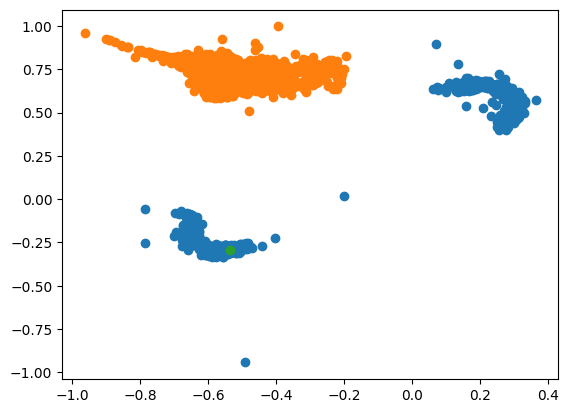

In [989]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.scatter(samples_misspecified[:, 0], samples_misspecified[:, 1])
plt.scatter(thetas[0, 0], thetas[0, 1])

In [1301]:
@hk.without_apply_rng
@hk.transform
def dist_model(y,x):
    net = hk.Sequential([
        hk.Linear(200), jax.nn.gelu,
        hk.Linear(200), jax.nn.gelu,
        hk.Linear(200), jax.nn.gelu,
        hk.Linear(10), jax.nn.gelu
    ])
    x_emb = net(x)
    y_emb = net(y)
    
    return jnp.linalg.norm(x_emb - y_emb, axis=-1)**2

init, apply = dist_model.init, dist_model.apply
params2 = init(jax.random.PRNGKey(1), jnp.ones(( input_dim,)),  jnp.ones(( input_dim,)))
d = apply

In [1302]:
ys = xs + 0.5

In [1303]:
# def loss_fn2(params2, key):
#     key1, key2, key3 = jax.random.split(key, 3)
#     xs_batch = jax.random.choice(jax.random.PRNGKey(0), xs, (50,))
#     ys_batch = jax.random.choice(key2, ys, (1000,))
#     thetas_batch = jax.random.choice(key3, thetas, (10,))
#     D = jax.vmap(jax.vmap(d, in_axes=(None, 0, None)), in_axes=(None, None, 0))(params2, xs_batch, ys_batch)
#     print(D.shape)
#     D = jax.nn.softmax(-D, axis=1)
#     D = jnp.mean(D, axis=0)
#     probs = jax.vmap(log_prob,in_axes=(None,0,None))(params, jnp.broadcast_to(thetas_batch[:,None,...], (10,) + xs_batch.shape), xs_batch)
#     weighted_probs = jnp.log(D)[None,...] + probs
#     weighted_sum = jax.scipy.special.logsumexp(weighted_probs, axis=-1)
#     return -weighted_sum.mean()


def loss_fn2(params2, key):
    key1, key2, key3 = jax.random.split(key, 3)
    xs_batch = jax.random.choice(jax.random.PRNGKey(0), xs, (1000,))
    thetas_batch = jax.random.choice(jax.random.PRNGKey(0), thetas, (1000,))
    xs_contrast = jax.random.choice(key3, xs, (1000,))
    ys_batch = jax.random.choice(key2, ys, (100,))
    
    probs = log_prob(params, thetas_batch, xs_batch)
    probs_contrast = log_prob(params, thetas_batch, xs_contrast)
    D = jax.vmap(jax.vmap(d, in_axes=(None, 0, None)), in_axes=(None, None, 0))(params2, xs_batch, ys_batch)
    D_contrast = jax.vmap(jax.vmap(d, in_axes=(None, 0, None)), in_axes=(None, None, 0))(params2, xs_contrast, ys_batch)
    D = jax.nn.log_softmax(-D, axis=1)
    D_contrast = jax.nn.log_softmax(-D_contrast, axis=1)

    weighted_probs_good = D  + probs
    weighted_probs_bad = D_contrast + probs_contrast
    weighted_probs_good = jax.scipy.special.logsumexp(weighted_probs_good, axis=-1)
    weighted_probs_bad = jax.scipy.special.logsumexp(weighted_probs_bad, axis=-1)

    cases = jnp.stack([weighted_probs_good, weighted_probs_bad], axis=1)   
    class_prob = jax.nn.log_softmax(cases, axis=1)
    l = -class_prob[:, 0].mean()

    return -weighted_probs_good.mean()


@jax.jit
def step(params2, opt_state, key):
    loss, g = jax.value_and_grad(loss_fn2)(params2, key)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params2, updates)

    return new_params, updated_state, loss
    

In [1304]:
optimizer = adam(1e-4)
opt_state = optimizer.init(params2)

In [1324]:
for i in range(16000):
    params2, opt_state, loss = step(params2, opt_state, jax.random.PRNGKey(i))
    if i % 200 == 0:
        print(loss)

-0.7633009
-0.90113676
-0.7240762
-0.67643464
-1.0296746
-0.84496903
-0.5610197
-0.8621581
-0.4471247
-0.97684497
-0.7408564
-0.715743
-0.7134236
-0.601966
-1.0187578
-0.97229874
-0.8462988
-0.890112
-0.8313619
-1.0606099
-0.7748392
-0.84227383
-1.1994648
-0.91323787
-0.8699744
-1.2176654
-1.2495621
-1.1487602
-0.6216849
-1.7144628
-0.706991
-1.0775471
-0.826146
-0.45165488
-1.2007129
-1.2028356
-0.74798566
-0.74278235
-1.1637312
-1.1984746
-0.80963147
-1.1991212
-1.6653576
-0.9083307
-0.90494865
-1.3264571
-1.3605438
-1.1611974
-1.30485
-1.102778
-0.94175184
-1.0065528
-1.322777
-1.1911038
-1.0001163
-1.1333008
-1.0663486
-1.5383077
-0.58061737
-0.96010375
-0.9316627
-1.0182135
-1.6660753
-0.87859434
-1.1614736
-1.3177382
-0.69420195
-1.3884827
-1.1749899
-0.50365615
-1.2025231
-1.3762808
-0.840107
-0.8898949
-1.07275
-0.87625194
-1.4270953
-1.7874975
-0.96966887
-1.1762785


In [1325]:
def sample_fn_misspecified(num_samples, key, context_y):
    key1, key2, key3 = jax.random.split(key, 3)
    xs_batch = jax.random.choice(jax.random.PRNGKey(0), xs, (1000,))
    d_yo = jax.vmap(d, in_axes=(None,0, None))(params2, xs_batch, context_y)
    #d_yo = jnp.ones_like(d_yo)
    idx = jax.random.choice(key2, jnp.arange(1000), (num_samples,), p=jax.nn.softmax(-d_yo, axis=0).flatten())
    xs_sample = xs_batch[idx]
    keys = jax.random.split(key3, (num_samples,))
    theta_samples = jax.vmap(sample_fn)(keys, xs_sample)
    return theta_samples, d_yo

In [1332]:
idx = 50

samples, d_yo = sample_fn_misspecified(2000, jax.random.PRNGKey(1), ys[idx])

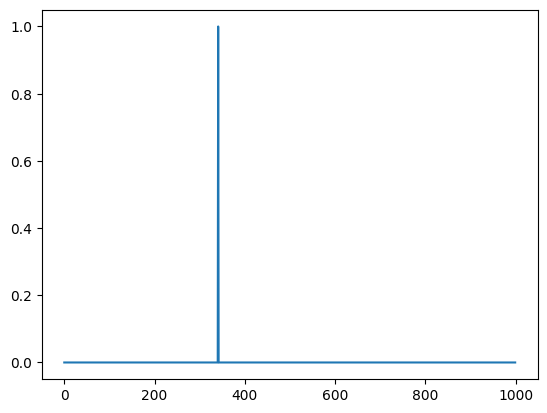

In [1333]:
plt.plot(jax.nn.softmax(d_yo))

(-1.0, 1.0)

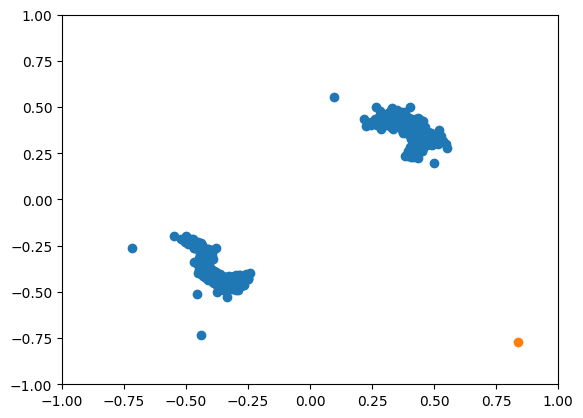

In [1334]:
plt.scatter(samples[:, 0], samples[:, 1])
plt.scatter(thetas[idx, 0], thetas[idx, 1])
plt.xlim(-1, 1)
plt.ylim(-1, 1)